## 4장 1강: 파이토치 기초 및 심층 신경망

### 6. 파이토치 기반 패션 이미지 다층 모델 실습
#### 6.1 데이터 준비 및 전처리
실습에 필요한 도구 불러오기 및 설정

In [1]:
import torch
from torchvision import datasets
from torchvision.transforms import ToTensor
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt

device = torch.device(
    "cuda" if torch.cuda.is_available() else
    "mps" if torch.backends.mps.is_available() else
    "cpu"
)

print(f"현재 사용중인 연산 디바이스: {device}")

현재 사용중인 연산 디바이스: cpu


Fashion MNIST 데이터 불러오기

In [2]:
# Fashion MNIST 28x28 (2차원 데이터) (0~255) -> 표준 점수 -> 특성은 1차원으로 변환 해야 합니다. 
#60.000 DATA -> 훈련 데이터는 50,000장, 검증 데이터는 10,000장 사용 예정

# 훈련 데이터 세트
raw_train_data = datasets.FashionMNIST(
    root="data", train = True, download=True, transform=ToTensor()
)
test_data = datasets.FashionMNIST(
    root="data", train = False, download=True, transform=ToTensor()
)

100.0%
100.0%
100.0%
100.0%


검증 데이터 세트 분리하기

In [3]:
# 검증 데이터 세트 분리 - 과적합 시점을 확인해 보기 위한 목적!!!!
# random_split을 활용해 60,000장의 훈련용 데이터를 훈련(50,000장)과 검증(10,000장)으로 분할
# seed를 고정(42)하여 실행할 때마다 동일하게 분할되도록 설정합니다.

train_size = 50000 # 훈련 세트 사이즈 지정
val_size = 10000 # 검증 세트 사이즈 지정 
# 파이토치가 제공한 데이터 사용/랜덤 스플릿 함수
train_data, val_data = random_split(
    raw_train_data, [train_size, val_size], 
    generator=torch.Generator().manual_seed(42)
)

print(f"훈련 세트: {len(train_data)}장 | 검증 세트: {len(val_data)}장 | 테스트 세트: {len(test_data)}장")


훈련 세트: 50000장 | 검증 세트: 10000장 | 테스트 세트: 10000장


데이터셋별 DataLoader 생성

In [ ]:
# batch size : 에포크에서 전 데이터셋을 32개의 배치로 분할 -> 미니배치 경사하강법 / 학습 데이터 정리
train_loader = DataLoader(train_data, batch_size=32, shuffle=True)   # 데이터 섞기 활성화 (과적합 방지)
val_loader = DataLoader(val_data, batch_size=32, shuffle=False)     # 평가는 섞을 필요 없음
test_loader = DataLoader(test_data, batch_size=32, shuffle=False)   # 평가는 섞을 필요 없음

**미니 배치(Mini-batch)와 데이터 셔플(Shuffle)의 필요성**

인공지능 모델을 학습시킬 때 전체 데이터를 한 번에 학습시키지 않고, `batch_size=32`와 같이 적당한 크기로 쪼개어 공급하는 방식을 **미니 배치 경사하강법(Mini-batch Gradient Descent)**이라고 합니다.

***미니 배치(batch_size=32)를 사용하는 이유***

<aside>
**메모리 한계 극복 (Memory Efficiency)**
수만 장의 이미지 데이터를 한 번에 GPU/CPU 메모리에 올리면 메모리 부족 오류(OOM, Out of Memory)가 발생합니다. 데이터를 32개씩 잘라 소량으로 나누어 연산함으로써 하드웨어 자원을 안정적으로 관리합니다.

**병렬 연산 속도 최적화 (Hardware Acceleration)**
현대 하드웨어(특히 GPU)는 병렬 행렬 연산에 최적화되어 있습니다. 데이터를 1개씩 처리하는 것보다 32개씩 묶어서 대형 행렬 연산으로 처리할 때 GPU의 병렬 하드웨어 가속 성능을 극대화하여 학습 시간을 대폭 단축할 수 있습니다.

**학습 안정성과 수렴 속도의 균형 (Optimization Balance)**
전체 데이터를 모두 보고 가중치를 바꾸면 연산이 너무 무겁고, 데이터 1개마다 가중치를 바꾸면 학습 방향이 너무 불안정하게 튑니다. 미니 배치는 적당한 규칙성과 무작위성(노이즈)을 동시에 제공하여 모델이 국소 최적점(Local Minima)에 갇히지 않고 빠르고 안정적으로 최적점에 수렴하도록 돕습니다.

</aside>

***데이터 셔플(shuffle)을 설정하는 이유***

<aside>
**훈련 데이터셋 (shuffle=True)**
특정 의류(예: 셔츠)만 연속으로 들어오거나 데이터가 일정한 순서대로 배치되어 있을 경우, 모델은 데이터의 본질이 아닌 '입력 순서의 패턴'을 잘못 암기하여 과적합을 일으킬 수 있습니다. 에포크마다 순서를 무작위로 뒤섞어 주어야 데이터 본연의 특징을 편견 없이 학습합니다.

**검증 및 테스트 데이터셋 (shuffle=False)**
평가 단계는 이미 동결된 가중치를 바탕으로 모델의 고정된 실전 정확도를 측정하는 정량 시험입니다. 데이터를 섞는 연산은 불필요한 자원을 소모할 뿐이며, 오답 분석이나 성능 디버깅 시 일관된 인덱스로 결과를 확인하기 위해 셔플을 해제합니다.

</aside>

In [ ]:
# 파이토치는 이미 데이터 전처리가 되어 있어요~ # 28x28 2차원 데이터 입니다
train_data[0]

(tensor([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.1529, 0.2353, 0.2000,
           0.2235, 0.1961, 0.2157, 0.2078, 0.1961, 0.1922, 0.1647, 0.1725,
           0.1804, 0.1843, 0.2353, 0.0431],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0078, 0.0000, 0.5216, 0.6196, 0.5922,
           0.7529, 0.7725, 0.8118, 0.7882, 

### 6.2 모델 설계

다층 퍼셉트론(MLP) 모델 클래스 정의

In [6]:
import torch.nn as nn # 신경망 만들 때 쓰는 도구 모음
import torch.optim as optim  # 옵티마이저



# 1. 다층 퍼셉트론(MLP) 모델 클래스 정의
class AdvancedFashionClassifier(nn.Module):

    # 사용할 층(layer)을 정의
    def __init__(self):
        super(AdvancedFashionClassifier, self).__init__()

        # 2D 이미지 [28, 28]를 1D 벡터 [784] 형태로 펼쳐주는 계층 : 즉, 2차원을 1차원으로 변경!
        # nn.Flatten() : 2차원 텐서 -> 1차원 텐서로 바꿔 주는 함수 [입력층]
        self.flatten = nn.Flatten()
        
        # 입력층(784) -> 은닉층(128) 선형 변환 [은닉층]
        self.hidden_layer = nn.Linear(784, 128)

        # 활성화 함수로 은닉층에 비선형성 주입을 위한 ReLU 지정 [은닉층/활성화 함수 설정!]
        self.relu = nn.ReLU()

        # 학습 중 뉴런의 20%를 무작위로 비활성화하는 드롭아웃 설정(0~1,0.1~0.5 사이로 설정) [과적합 방지 - 드롭아웃 설정!]
        self.dropout = nn.Dropout(p=0.2)

        # 은닉층(128) -> 출력층(10) 선형 변환 [출력층]
        self.output_layer = nn.Linear(128, 10)


    # 순전파(Feed Forward) 
    def forward(self, x):
        out = self.flatten(x) # [입력층] 처리
        out = self.hidden_layer(out) # [은닉층] 처리 
        out = self.relu(out)    # [은닉층/활성화 함수] 처리 - 선형적 -> 비선형적으로 변형
        out = self.dropout(out)  # 훈련시에만/예측시에는 쓰지 않습니다!/과적합 방지를 위해 통과 시킨 것!
        out = self.output_layer(out)  # 별도의 Softmax 없이 Raw 점수(Logits) 출력
        return out


모델 인스턴스 생성 및 연산 디바이스(GPU/MPS/CPU)로 할당

In [8]:
# 모델 인스턴스 생성 및 연산 디바이스(GPU/MPS/CPU)로 할당
# 할당된 디바이스 메모리로 가중치(Weights)와 편향(Bias) 파라미터가 이동합니다.
model = AdvancedFashionClassifier().to(device)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f" 학습 가능한 총 파라미터 수: {total_params:,}개")


 학습 가능한 총 파라미터 수: 101,770개


손실 함수 및 옵티마이저 정의
- nn.CrossEntropyLoss는 내부적으로 Softmax 연산을 포함합니다

In [10]:
# 손실 함수 및 옵티마이저 정의
# nn.CrossEntropyLoss는 내부적으로 Softmax 연산을 포함합니다.
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.005)

### 6.3 조기 종료 학습 및 검증 루프
- 훈련 데이터셋으로 가중치를 업데이트하고, 에포크마다 검증 데이터셋의 손실을 추적합니다. 설정한 에포크(patience) 동안 검증 손실이 개선되지 않으면 학습을 자동으로 강제 중단(Early Stopping)하고 최적의 가중치를 저장합니다.

In [11]:
# 조기 종료(Early Stopping)를 위한 하이퍼파라미터 및 변수 설정
epochs = 20                 # 최대 허용 에포크 수
patience = 3                # 검증 손실이 개선되지 않는 상태를 참아줄 최대 횟수
patience_counter = 0        # 카운터 초기화
best_val_loss = float('inf') # 최적의 검증 손실 기준점을 무한대로 초기화

train_losses = []
val_losses = []

print("\n=== 모델 학습 및 검증을 시작합니다 ===")
for epoch in range(epochs):
    # --- [훈련 모드] ---
    running_loss = 0.0
    model.train()  # 드롭아웃 등 훈련 전용 기능 활성화
    
    for images, labels in train_loader:
        # 미니배치 데이터를 모델이 위치한 동일 가속기 메모리로 이관합니다.
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()       # 이전 기울기 초기화
        outputs = model(images)     # 순방향 예측
        loss = criterion(outputs, labels)  # 손실 계산
        loss.backward()             # 오차 역전파 수행
        optimizer.step()            # 옵티마이저를 통한 가중치 업데이트
        
        running_loss += loss.item() # 배치마다의 로스를 기록(1에포크)
        
    epoch_loss = running_loss / len(train_loader) # 1에포그 로스(배치 로스의 평균)
    train_losses.append(epoch_loss)
    
    # --- [평가/검증 모드] ---
    model.eval()  # 드롭아웃 등 평가 시 배제되어야 하는 기능 /비활성화 / 학습할때만 쓰는거니깐 드롭아웃을 배제하는 것
    val_loss = 0.0
    
    with torch.no_grad():  # 검증 시에는 미분 계산을 제한하여 연산 자원 최적화
        for images, labels in val_loader:
            # 평가 단계의 미니배치 데이터도 동일하게 가속기로 이관합니다.
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()

           
    epoch_val_loss = val_loss / len(val_loader)
    val_losses.append(epoch_val_loss)
    
    print(f"Epoch [{epoch+1}/{epochs}] | 훈련 손실: {epoch_loss:.4f} | 검증 손실: {epoch_val_loss:.4f}")
    # 과적합 시점이 발생하면, 훈련을 멈춰야 합니다. - 조기종료

    
    
    # --- 조기 종료 조건 검증 로직 ---
    if epoch_val_loss < best_val_loss:
        # 검증 손실이 기존 최적값보다 개선된 경우
        best_val_loss = epoch_val_loss
        patience_counter = 0  # 카운터 리셋
        # 최적의 모델 가중치를 파일로 저장
        torch.save(model.state_dict(), "best_fashion_model.pth")
        print(f" => 최적 모델 저장 완료 (최저 검증 손실: {best_val_loss:.4f})")
    else:
        # 검증 손실이 개선되지 않은 경우
        patience_counter += 1
        print(f" => 검증 손실 미개선 (조기 종료 대기 카운트: {patience_counter}/{patience})")
        
        # 설정한 참을성(Patience) 한계를 초과하면 학습을 강제 중단
        if patience_counter >= patience:
            print(f"\n[Early Stopping 활성화] {epoch+1} 에포크에서 학습을 조기 종료합니다.")
            break


=== 모델 학습 및 검증을 시작합니다 ===
Epoch [1/20] | 훈련 손실: 0.5656 | 검증 손실: 0.4481
 => 최적 모델 저장 완료 (최저 검증 손실: 0.4481)
Epoch [2/20] | 훈련 손실: 0.4705 | 검증 손실: 0.4280
 => 최적 모델 저장 완료 (최저 검증 손실: 0.4280)
Epoch [3/20] | 훈련 손실: 0.4435 | 검증 손실: 0.4209
 => 최적 모델 저장 완료 (최저 검증 손실: 0.4209)
Epoch [4/20] | 훈련 손실: 0.4247 | 검증 손실: 0.3884
 => 최적 모델 저장 완료 (최저 검증 손실: 0.3884)
Epoch [5/20] | 훈련 손실: 0.4099 | 검증 손실: 0.3759
 => 최적 모델 저장 완료 (최저 검증 손실: 0.3759)
Epoch [6/20] | 훈련 손실: 0.4012 | 검증 손실: 0.3753
 => 최적 모델 저장 완료 (최저 검증 손실: 0.3753)
Epoch [7/20] | 훈련 손실: 0.3953 | 검증 손실: 0.3784
 => 검증 손실 미개선 (조기 종료 대기 카운트: 1/3)
Epoch [8/20] | 훈련 손실: 0.3879 | 검증 손실: 0.3696
 => 최적 모델 저장 완료 (최저 검증 손실: 0.3696)
Epoch [9/20] | 훈련 손실: 0.3792 | 검증 손실: 0.3753
 => 검증 손실 미개선 (조기 종료 대기 카운트: 1/3)
Epoch [10/20] | 훈련 손실: 0.3754 | 검증 손실: 0.3737
 => 검증 손실 미개선 (조기 종료 대기 카운트: 2/3)
Epoch [11/20] | 훈련 손실: 0.3740 | 검증 손실: 0.4133
 => 검증 손실 미개선 (조기 종료 대기 카운트: 3/3)

[Early Stopping 활성화] 11 에포크에서 학습을 조기 종료합니다.


### 6.4 최종 테스트셋 기반 정확도 측정 및 시각화
- 학습 과정 중 검증 손실이 가장 낮았던 최적의 모델 가중치를 파일로부터 복원합니다. 이후 학습과 검증에 전혀 관여하지 않은 순수한 테스트 데이터셋(Test Set)을 투입하여 모델의 실전 분류 정확도(Accuracy)를 객관적으로 측정하고 최종 손실 곡선을 출력합니다.

In [12]:
# 가장 좋은 학습 가중치의 모델을 불러오기!


model.load_state_dict(torch.load("best_fashion_model.pth"))
model.to(device)



AdvancedFashionClassifier(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (hidden_layer): Linear(in_features=784, out_features=128, bias=True)
  (relu): ReLU()
  (dropout): Dropout(p=0.2, inplace=False)
  (output_layer): Linear(in_features=128, out_features=10, bias=True)
)

테스트 / 평가 모델 돌리기

In [13]:
# 테스트셋 기반 최종 실전 정확도(Accuracy) 측정
model.eval()  # 추론 및 평가 모드로 고정
correct = 0
total = 0


with torch.no_grad():  # 평가 단계이므로 미분 계산 비활성화
    for images, labels in test_loader:
        # 테스트 데이터셋 역시 연산 전 가속기로 이동시킵니다.
        images = images.to(device)
        labels = labels.to(device)
        
        outputs = model(images)
        # 각 행(인스턴스)별로 10개 카테고리 중 가장 높은 점수를 받은 인덱스 추출
        _, predicted = torch.max(outputs.data, 1)  
        print("predicted:",predicted)
        
        total += labels.size(0)                       # 전체 데이터 개수 누적
        correct += (predicted == labels).sum().item()  # 정답을 맞춘 개수 누적


# 정확도 평가 
test_accuracy = 100 * correct / total  # 퍼센트
print(f"테스트 세트 정확도 : {test_accuracy:.4f}%")



predicted: tensor([9, 2, 1, 1, 6, 1, 4, 6, 5, 7, 4, 5, 5, 3, 4, 1, 2, 2, 8, 0, 2, 5, 7, 5,
        1, 2, 6, 0, 9, 4, 8, 8])
predicted: tensor([3, 3, 8, 0, 7, 5, 7, 9, 0, 1, 6, 7, 6, 7, 2, 1, 2, 6, 2, 2, 5, 8, 2, 2,
        8, 4, 8, 0, 7, 7, 8, 5])
predicted: tensor([1, 1, 6, 4, 7, 8, 7, 0, 2, 6, 2, 3, 1, 2, 8, 4, 1, 8, 5, 9, 5, 0, 3, 2,
        0, 2, 5, 3, 6, 7, 1, 8])
predicted: tensor([0, 1, 2, 2, 3, 6, 7, 6, 7, 8, 5, 7, 9, 4, 2, 5, 7, 0, 5, 2, 8, 6, 7, 8,
        0, 0, 9, 9, 3, 0, 8, 2])
predicted: tensor([1, 5, 4, 1, 9, 1, 8, 6, 6, 1, 2, 5, 1, 6, 0, 0, 1, 6, 1, 3, 2, 2, 3, 6,
        1, 3, 5, 0, 4, 7, 9, 3])
predicted: tensor([7, 2, 3, 9, 0, 9, 4, 7, 4, 2, 6, 5, 2, 1, 2, 1, 3, 0, 9, 1, 0, 9, 3, 6,
        7, 9, 9, 4, 4, 7, 1, 2])
predicted: tensor([1, 2, 3, 2, 8, 3, 6, 1, 1, 0, 2, 9, 2, 4, 0, 7, 9, 8, 4, 1, 8, 4, 1, 3,
        1, 6, 7, 2, 8, 5, 6, 0])
predicted: tensor([7, 7, 6, 6, 7, 0, 7, 8, 9, 2, 9, 0, 5, 1, 4, 2, 5, 4, 9, 2, 2, 8, 6, 4,
        2, 4, 9, 7, 6, 5, 5, 2])
predicte

c:\Users\jihyu\Documents\AX_study\04.Machine Learning\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 49552 (\N{HANGUL SYLLABLE SON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\jihyu\Documents\AX_study\04.Machine Learning\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 49892 (\N{HANGUL SYLLABLE SIL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\jihyu\Documents\AX_study\04.Machine Learning\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 53356 (\N{HANGUL SYLLABLE KEU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\jihyu\Documents\AX_study\04.Machine Learning\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 44592 (\N{HANGUL SYLLABLE GI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\jihyu\Documents\AX_study\04.Machine Learning

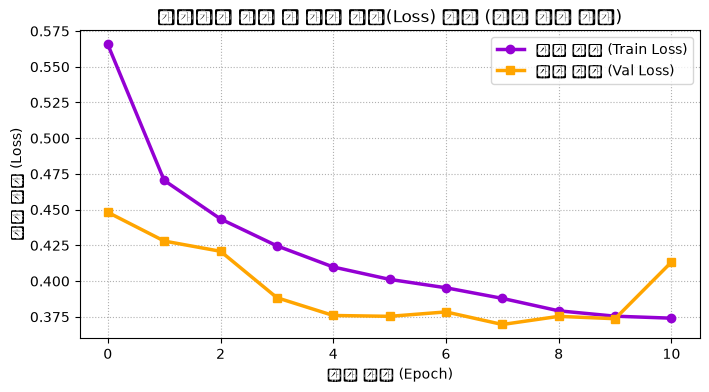

In [14]:
# 3. 에포크별 훈련 및 검증 손실 곡선 시각화
plt.figure(figsize=(8, 4))
plt.plot(train_losses, marker='o', color='darkviolet', linewidth=2.5, label='훈련 손실 (Train Loss)')
plt.plot(val_losses, marker='s', color='orange', linewidth=2.5, label='검증 손실 (Val Loss)')
plt.title("에포크별 훈련 및 검증 손실(Loss) 추이 (조기 종료 적용)")
plt.xlabel("학습 횟수 (Epoch)")
plt.ylabel("손실 크기 (Loss)")
plt.legend()
plt.grid(True, linestyle=':')
plt.show()

===

# 수업 내용
---
* 하단 질문 사항에 대해 정리해줘,
은닉층에 추가되는 활성화 함수
- 선형적 -> 비선형적 으로
- 과거형 함수 : 시그모이드 (0 ~ 1사이로 압축하므로 은닉층에 과거에 사용되던 함수)


입력층 -> 은닉층 -> 출력층

입력층 -> 은닉층 -> 은닉층 -> 출력층
- 은닉층을 통과할 때마다 가중치가 작아진다
- 가중치가 작아지므로, 변경하는 이유가 미미하므로 학습하는 의미가 사라진다 = 그라디언트 소실 현상



ReLU함수 
    =max(z,o) -> 음수는 0, 양수는 그대로 통과시키는 함수






- 파이토치 개념과 머신러닝과의 상관관계?
- 입력층 ->은닉층이 왜 필요한지?
- 은닉층이 무엇인지?
- 파라미터는 무엇인지?
- 역전파는 무엇인지?
- 기울기 소실은 무엇인지?
- 합성곱 신경망은 무엇인지?
- 다층 퍼셉트론 모델 파라미터가 뭐야? 워딩이 너무 어려워
- 단층모델/다층모델은 왜 생기는거야?
- 모델 파라미터(가중치와 편향)가 뭐야?
- 교안에 나오는 은닉층의 뉴런 추가가 뭐야? 
- ReLU함수 : 이것도 활성 함수야? 이거는 어디에 쓰는 함수야?
- 출력층에 함수가 필요한데 은닉층이 생기면서 거기에도 함수가 필요해? 
- 은닉층 활성화 함수도 소프트맥스 함수야?


===
실습 예제
===